# 1) pyGIMLi ERT manager

To start, we want to get to know pyGIMLi's capabilities for ERT data, accessible through in `pygimli.physics.ert`.

This package contains **tools, modelling operators, and managers** for Electrical Resistivity Tomography (ERT) & Induced polarization (IP) data, supplying you with tools to **load, visualize, process and invert** your ERT or IP field data.

The main classes are:

* `DataContainer(ERT)` - ERT/IP-specific data container

* `ERTModelling` - Modelling operator

* `ERTManager` - data inversion and modelling for real resistivity

* `ERTIPManager` - extension to IP (either frequency or time domain)

* `TimelapseERT` - processing and inversion of timelapse ERT data

* `CrossholeERT` - timelapse ERT in crosshole environments

This notebook should provide an **overview of the most basic operations** to help you process your own field data. 
To ensure the learning outcomes, we will provide a data set in case you do not have any own data on hand. 

**But we encourage you to process your own data during this workshop!**

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pygimli as pg

from pygimli.physics import ert
import pygimli.meshtools as mt

## 1.1 Data import and sensor position definition

In [3]:
data = pg.load("../data/ERT_DD_filtered.dat")

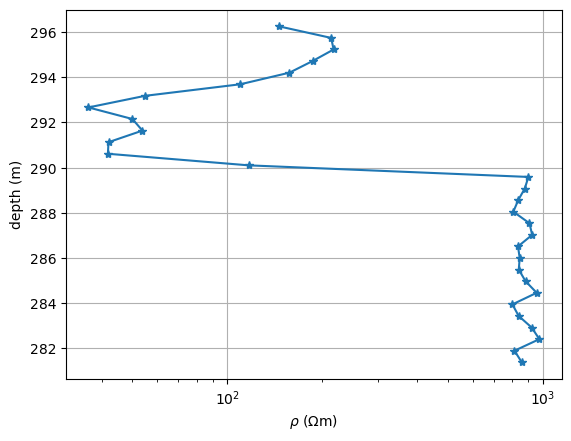

In [6]:
x, z, r = np.load('../data/x.npy'), np.load('../data/z.npy'), np.load('../data/r.npy')
fig, ax = plt.subplots()
ax.semilogx(r, z, "*-")
ax.set_xlabel(r"$\rho$ ($\Omega$m)")
ax.set_ylabel("depth (m)")
ax.grid(True)

## 1.2 Data container structure and data visualization

(<Axes: >, <matplotlib.colorbar.Colorbar at 0x7038b1726250>)

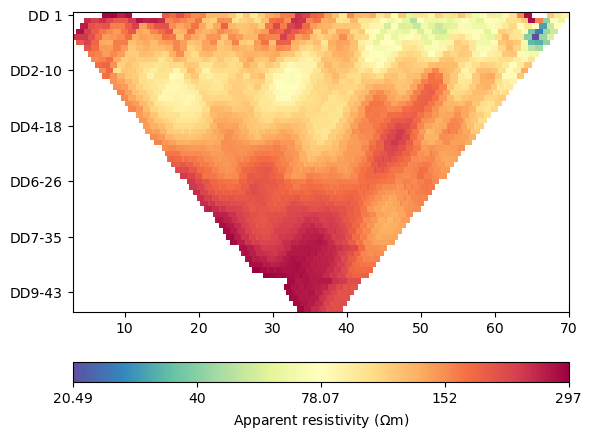

In [4]:
ert.show(data)

16/09/26 - 13:54:53 - pyGIMLi - INFO - Found 2 regions.
16/09/26 - 13:54:53 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.


Mesh: Nodes: 2907 Cells: 5548 Boundaries: 8454


(<Axes: xlabel='$x$ in m', ylabel='$y$ in m'>, None)

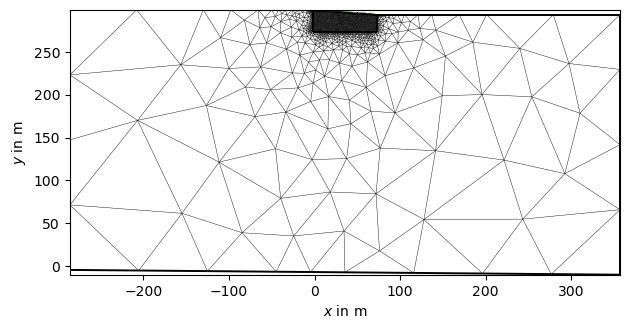

In [5]:
mgr = ert.ERTManager(data)
plc = mt.createParaMeshPLC(data.sensorPositions(), paraDX=0.33, paraDepth=20, paraMaxCellSize=0.75)

mesh = mt.createMesh(plc)
mgr.setMesh(mesh)
print(mesh)
pg.show(mesh)

## 1.5 First inversion and quality evaluation

In [6]:
invArgs = dict(lam = 45, robustData=False, blockyModel=False, verbose=True)

mgr = ert.ERTManager(data)
inv = mgr.invert(mesh=mesh, **invArgs)

16/09/26 - 13:54:53 - pyGIMLi - INFO - Found 2 regions.
16/09/26 - 13:54:53 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
16/09/26 - 13:54:53 - pyGIMLi - INFO - Creating forward mesh from region infos.
16/09/26 - 13:54:53 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
16/09/26 - 13:54:53 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 11361 Cells: 22192 Boundaries: 16908
16/09/26 - 13:54:54 - pyGIMLi - INFO - Use median(data values)=144.315107136596
16/09/26 - 13:54:54 - pyGIMLi - INFO - Created startmodel from forward operator:4531, min/max=144.315107/144.315107
16/09/26 - 13:54:54 - pyGIMLi - INFO - Starting inversion.


min/max(dweight) = 56.5126/57.099
fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x7038b3505ad0>
Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
Model transformation: Logarithmic transform
min/max (data): 20.49/297
min/max (error): 1.75%/1.77%
min/max (start model): 144/144
--------------------------------------------------------------------------------
Calculating response for model: min = 144.315 max = 144.315
Allocating memory for primary potential...... 0.0937467

No primary potential for secondary field calculation with topography.
Creating P2-Primmesh:		Nodes: 44913	Cells: 22192	Boundaries: 33552
ModellingBase::setMesh() copying new mesh ... Found topography for surface=297.486 : 297.514
Found datafile: 72 electrodes
Found: 72 node-electrodes
rMin = 0.5, rMax = 142.444
NGauLeg + NGauLag for inverse Fouriertransformation: 14 + 4
Found non-Neumann domain
0.075823 s
FOP updating mesh dependencies ... 1.867e-06 s
Forward: time: 108.244s


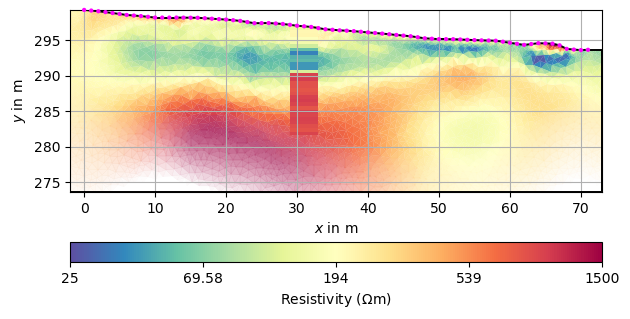

In [7]:
from pygimli.viewer.mpl import draw1DColumn


kw = dict(
    cMin=25, cMax=1500, logScale=True, cMap="Spectral_r",
    xlabel="x (m)", ylabel="y (m)")
ax, cb = mgr.showResult(**kw)
zz = np.abs(z[::-1])
iz = np.argsort(z[::-1])
dz = np.diff(zz[iz])
thk = np.hstack([dz, dz[-1]])
ztop = -zz[iz[0]]-dz[0]/2
colkw = dict(x=x[0], val=r[iz], thk=thk, width=4, ztopo=-ztop+sum(thk))
draw1DColumn(ax, **colkw, **kw)
ax.grid(True)

In [8]:
from pygimli.frameworks import PriorModelling, JointModelling
posVec = [pg.Pos(pos) for pos in zip(x, z)]
para = pg.Mesh(mgr.paraDomain)  # make a copy
para.setCellMarkers(pg.IVector(para.cellCount()))
fopDP = PriorModelling(para, posVec)

16/09/26 - 14:01:15 - pyGIMLi - INFO - Found 1 regions.


In [9]:
# fopERT = ert.ERTModelling()
# fopERT.setMesh(mesh)
# fopERT.setData(data) # not necessary as done by JointModelling
# fopJoint = JointModelling([fopERT, fopDP])
fopJoint = JointModelling([mgr.fop, fopDP])
# fopJoint.setMesh(para)
fopJoint.setData([data, pg.Vector(r)]) 

Found datafile: 72 electrodes
Found: 72 node-electrodes
Found non-Neumann domain
 updateDataDependency:: cleaning primpot


16/09/26 - 14:01:15 - pyGIMLi - INFO - Starting inversion.


min/max(dweight) = 5/57.099
fop: <pygimli.frameworks.modelling.JointModelling object at 0x7038b11c3b00>
Data transformation: Logarithmic transform
Model transformation: Logarithmic transform
min/max (data): 20.49/998
min/max (error): 1.75%/20%
min/max (start model): 144/144
--------------------------------------------------------------------------------
Calculating response for model: min = 144.315 max = 144.315
Allocating memory for primary potential...... 0.0212083

No primary potential for secondary field calculation with topography.
Creating P2-Primmesh:		Nodes: 44913	Cells: 22192	Boundaries: 33552
ModellingBase::setMesh() copying new mesh ... Found topography for surface=297.486 : 297.514
Found datafile: 72 electrodes
Found: 72 node-electrodes
rMin = 0.5, rMax = 142.444
NGauLeg + NGauLag for inverse Fouriertransformation: 14 + 4
Found non-Neumann domain
0.073707 s
FOP updating mesh dependencies ... 2.068e-06 s
Forward: time: 93.9959s
Interpolating to secondary mesh

1296 	/ 1296
F

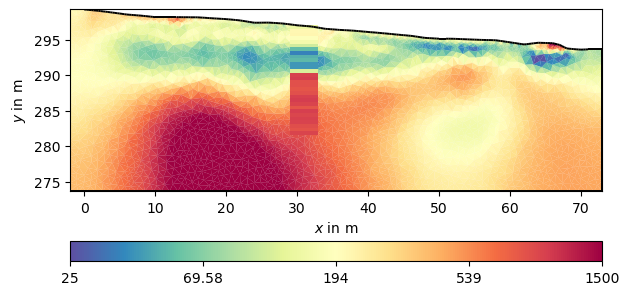

In [10]:
dataVec = np.concatenate((data["rhoa"], r))
errorVec = np.concatenate((data["err"], np.ones_like(r)*0.2))
inv = pg.Inversion(fop=fopJoint, verbose=True)
transLog = pg.trans.TransLog()
inv.modelTrans = transLog
inv.dataTrans = transLog
inv.run(dataVec, errorVec, startModel=np.median(data['rhoa']))
ax, cb = pg.show(para, inv.model, **kw)
draw1DColumn(ax, **colkw, **kw)

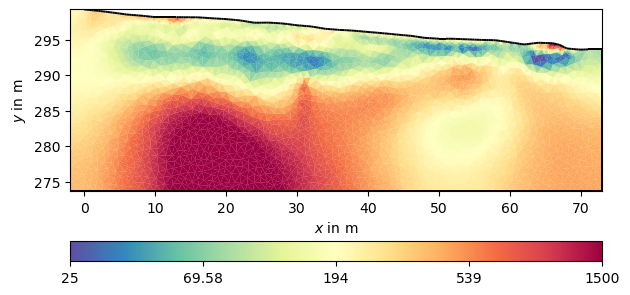

In [11]:
ax, cb = pg.show(para, inv.model, **kw)

16/09/26 - 14:07:30 - pyGIMLi - INFO - Starting inversion.


min/max(dweight) = 5/57.099
fop: <pygimli.frameworks.modelling.JointModelling object at 0x7038b11c3b00>
Data transformation: Logarithmic transform
Model transformation (cumulative):
	 0 Logarithmic LU transform, lower bound 0.0, upper bound 0.0
min/max (data): 20.49/998
min/max (error): 1.75%/20%
min/max (start model): 144/144
--------------------------------------------------------------------------------
use model trans from RegionManager


16/09/26 - 14:07:45 - pyGIMLi - INFO - Creating GeostatisticConstraintsMatrix for region 2 with: I=[5, 1], dip=0, strike=0
16/09/26 - 14:07:45 - pyGIMLi - INFO - Creating forward mesh from region infos.
16/09/26 - 14:07:45 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.


Calculating response for model: min = 144.315 max = 144.315
Using existing primary potentials.
Forward: time: 14.1231s
Response: min = 143.803 max = 145.188 mean = 144.314
Reciprocity rms(modelReciprocity) 0%, max: 0%
min/max(dweight) = 5/57.099
Building constraints matrix


16/09/26 - 14:07:45 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 11361 Cells: 22192 Boundaries: 16908


ModellingBase::setMesh() copying new mesh ... 0.0377554 s
FOP updating mesh dependencies ... 4.64e-05 s


16/09/26 - 14:09:34 - pyGIMLi - INFO - (C) Time for eigenvalue decomposition 108.0s
16/09/26 - 14:09:34 - pyGIMLi - INFO - Cache stored: /home/alexubuntuwsl/.cache/pygimli/11296615564219800701


constraint matrix of size(nBounds x nModel) 4531 x 4531
Calculating Jacobian matrix (forced=1)...Using existing subpotentials for createJacobian.
S(14/14-std::mt): 0.112906:time: 13.5602s
sens sum: median = 1.05702 min = 0.951192 max = 1.23925
... 13.6096 s
min data = 20.4942 max data = 997.712 (2933)
min error = 0.0175134 max error = 0.2 (2933)
min response = 143.803 max response = 145.188 (2933)
calc without reference model
0: rms/rrms(data, response) = 79.6142/45.3608%
0: chi^2(data, response, error, log) = 409.649
0: Phi = 1.2015e+06 + 7.55324e-25 * 20 = inv.iter 0 ... chi² =  409.65
1.2015e+06
--------------------------------------------------------------------------------
inv.iter 1 ... solve CGLSCDWWtrans with lambda = 20
Calculating response for model: min = 5.79913 max = 2595.05
Using existing primary potentials.
Forward: time: 16.8711s
Response: min = 16.1925 max = 347.261 mean = 130.898
Reciprocity rms(modelReciprocity) 2.00889%, max: 60.6704%
1: LS newModel: min = 5.79913; 

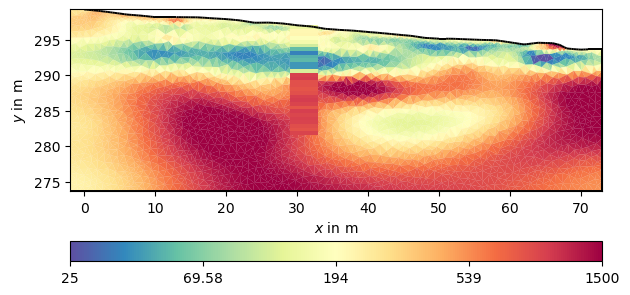

In [12]:
inv.setRegularization(2, correlationLengths=[5, 1])
model = inv.run(dataVec, errorVec, startModel=np.median(data['rhoa']))
ax, cb = pg.show(para, model, **kw)
draw1DColumn(ax, **colkw, **kw)